# Credit Card Fraud Detection — Handling Class Imbalance
Fraud detection is the classic imbalanced classification problem: fraud cases are a tiny fraction of all
transactions. This notebook checks the imbalance, visualizes it, applies SMOTE and class-weighting, and
compares model performance before vs. after.

**Dataset:** creditcard.csv — 284,807 transactions, 492 fraud (Class = 1), 284,315 normal (Class = 0)

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

In [2]:
df = pd.read_csv('creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Class Balance Check

In [3]:
class_counts = df['Class'].value_counts()
fraud_rate = df['Class'].mean()

print(class_counts)
print(f"\nFraud rate: {fraud_rate:.4%}")
print(f"Imbalance ratio: {class_counts[0] / class_counts[1]:.1f} : 1  (normal : fraud)")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%
Imbalance ratio: 577.9 : 1  (normal : fraud)


/tmp/ipykernel_505/1729736166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2c3e50', '#c0392b'])


/tmp/ipykernel_505/1729736166.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'])


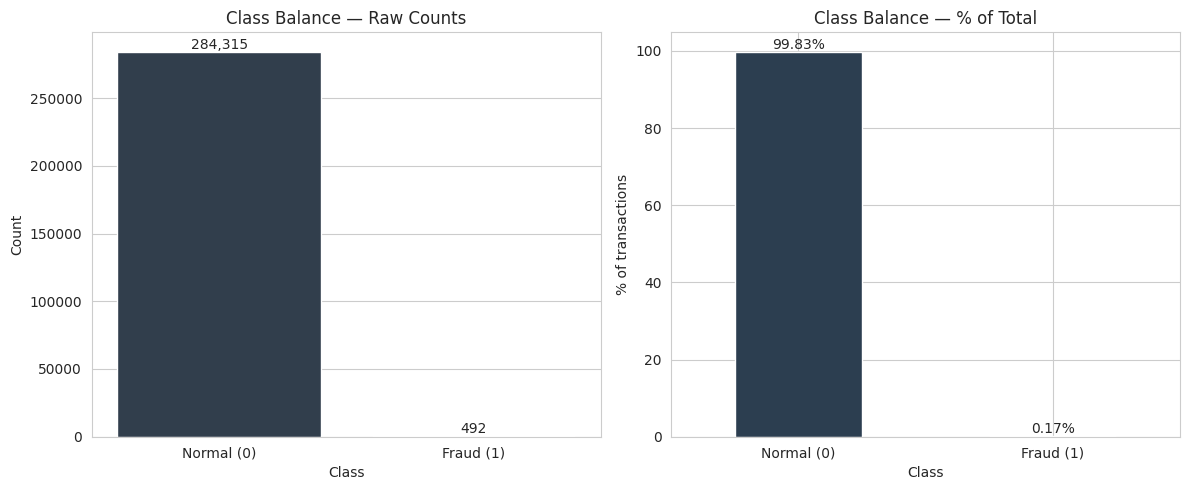

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2c3e50', '#c0392b'])
axes[0].set_title('Class Balance — Raw Counts')
axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'])
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=10)

(class_counts / class_counts.sum() * 100).plot(kind='bar', ax=axes[1], color=['#2c3e50', '#c0392b'])
axes[1].set_title('Class Balance — % of Total')
axes[1].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
axes[1].set_ylabel('% of transactions')
for i, v in enumerate((class_counts / class_counts.sum() * 100)):
    axes[1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Observation:** Fraud makes up only **0.17%** of all transactions (492 out of 284,807) — a
**~578 : 1** imbalance. This is far more extreme than the churn dataset from earlier tasks (~2.8:1) and is a
realistic picture of fraud, disease, and other rare-event detection problems.

## 3. Why Accuracy Would Be a Misleading Metric Here

With a 578:1 imbalance, a model that **always predicts "not fraud"** would score:

- Accuracy: 99.83%
- Fraud caught (recall): 0%

A 99.83% accuracy sounds excellent on paper, but that model is completely useless — it would let every
single fraudulent transaction through undetected while looking almost perfect on the one metric most
people check first. Accuracy is dominated by the majority class, so on heavily imbalanced data it hides
exactly the failure mode we care about most: missing the rare, high-cost cases. This is why **Precision,
Recall, F1, and ROC-AUC** are the metrics that actually matter here — Recall tells us what fraction of real
fraud we caught, Precision tells us how many fraud alerts were false alarms, and F1 balances the two.

In [5]:
# Proof: a "predict everything as not fraud" baseline
baseline_pred = np.zeros(len(df))
print(f"Baseline 'always predict not-fraud' accuracy: {accuracy_score(df['Class'], baseline_pred):.4%}")
print(f"Baseline 'always predict not-fraud' recall on fraud: {recall_score(df['Class'], baseline_pred):.4%}")

Baseline 'always predict not-fraud' accuracy: 99.8273%
Baseline 'always predict not-fraud' recall on fraud: 0.0000%


## 4. Train/Test Split & Scaling

In [6]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Time and Amount (the only unscaled raw features; V1-V28 are already PCA-scaled)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print(f"Train fraud cases: {y_train.sum()} / {len(y_train)}  ({y_train.mean():.4%})")
print(f"Test fraud cases:  {y_test.sum()} / {len(y_test)}  ({y_test.mean():.4%})")

Train fraud cases: 394 / 227845  (0.1729%)
Test fraud cases:  98 / 56962  (0.1720%)


## 5. Baseline Model — No Imbalance Handling

In [7]:
def eval_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_proba)
    }

# Plain Logistic Regression, no imbalance handling at all
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_scaled, y_train)
base_pred = lr_base.predict(X_test_scaled)
base_proba = lr_base.predict_proba(X_test_scaled)[:, 1]

base_result = eval_model('Logistic Regression (baseline, imbalanced)', y_test, base_pred, base_proba)
pd.DataFrame([base_result])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,"Logistic Regression (baseline, imbalanced)",0.999157,0.828947,0.642857,0.724138,0.955898


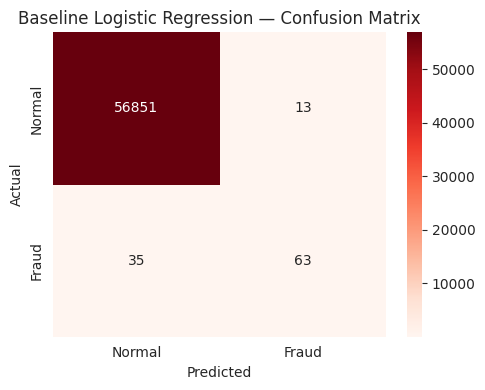

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [8]:
cm = confusion_matrix(y_test, base_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Baseline Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, base_pred, target_names=['Normal', 'Fraud']))

**Baseline takeaway:** Accuracy looks near-perfect (>99.9%), but look at Recall — the model is missing a
meaningful chunk of actual fraud cases because it was trained on data where "predict normal" is almost
always the safe bet. This is the imbalance problem in action.

## 6. Fix #1 — Class Weighting (`class_weight='balanced'`)

In [9]:
lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_weighted.fit(X_train_scaled, y_train)
weighted_pred = lr_weighted.predict(X_test_scaled)
weighted_proba = lr_weighted.predict_proba(X_test_scaled)[:, 1]

weighted_result = eval_model('Logistic Regression (class_weight=balanced)', y_test, weighted_pred, weighted_proba)
pd.DataFrame([weighted_result])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (class_weight=balanced),0.975528,0.060976,0.918367,0.114358,0.972169


## 7. Fix #2 — SMOTE Oversampling (applied to training data only)

In [10]:
# SMOTE synthesizes new minority-class (fraud) examples so the classes are balanced 1:1 in training.
# IMPORTANT: SMOTE is fit only on the training set, never on the test set, to avoid data leakage.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


In [11]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
smote_pred = lr_smote.predict(X_test_scaled)
smote_proba = lr_smote.predict_proba(X_test_scaled)[:, 1]

smote_result = eval_model('Logistic Regression (SMOTE)', y_test, smote_pred, smote_proba)
pd.DataFrame([smote_result])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (SMOTE),0.974211,0.058027,0.918367,0.109157,0.969863


## 8. Decision Tree — Baseline vs. Balanced (for cross-check)

In [12]:
dt_base = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_base.fit(X_train_scaled, y_train)
dt_base_pred = dt_base.predict(X_test_scaled)
dt_base_proba = dt_base.predict_proba(X_test_scaled)[:, 1]

dt_weighted = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt_weighted.fit(X_train_scaled, y_train)
dt_weighted_pred = dt_weighted.predict(X_test_scaled)
dt_weighted_proba = dt_weighted.predict_proba(X_test_scaled)[:, 1]

dt_base_result = eval_model('Decision Tree (baseline, imbalanced)', y_test, dt_base_pred, dt_base_proba)
dt_weighted_result = eval_model('Decision Tree (class_weight=balanced)', y_test, dt_weighted_pred, dt_weighted_proba)
pd.DataFrame([dt_base_result, dt_weighted_result])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,"Decision Tree (baseline, imbalanced)",0.999473,0.895349,0.785714,0.836957,0.901076
1,Decision Tree (class_weight=balanced),0.976265,0.058451,0.846939,0.109354,0.892712


## 9. Before vs. After — Full Comparison

In [13]:
all_results = pd.DataFrame([
    base_result,
    weighted_result,
    smote_result,
    dt_base_result,
    dt_weighted_result,
]).round(4)
all_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,"Logistic Regression (baseline, imbalanced)",0.9992,0.8289,0.6429,0.7241,0.9559
1,Logistic Regression (class_weight=balanced),0.9755,0.0610,0.9184,0.1144,0.9722
2,Logistic Regression (SMOTE),0.9742,0.0580,0.9184,0.1092,0.9699
3,"Decision Tree (baseline, imbalanced)",0.9995,0.8953,0.7857,0.8370,0.9011
4,Decision Tree (class_weight=balanced),0.9763,0.0585,0.8469,0.1094,0.8927


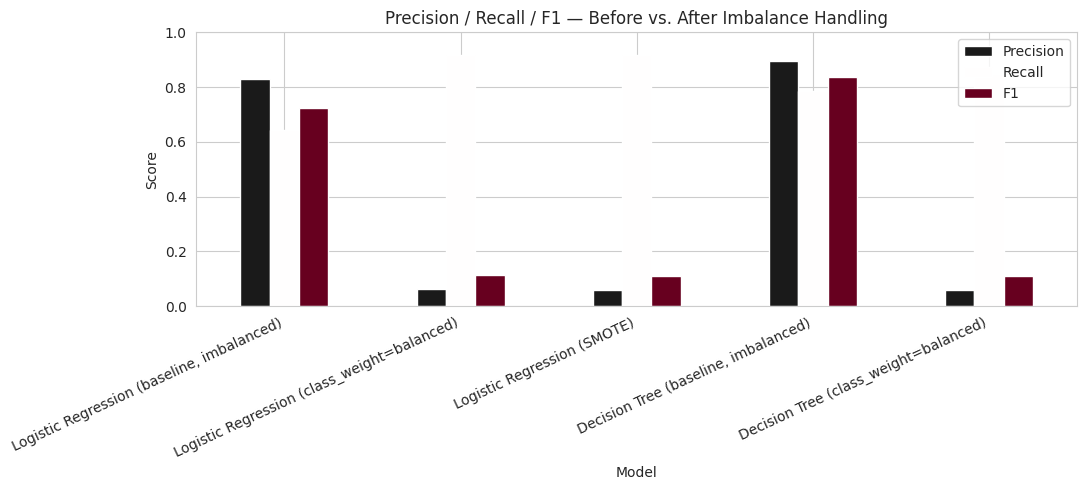

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
metrics_to_plot = ['Precision', 'Recall', 'F1']
all_results.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax, colormap='RdGy_r')
ax.set_title('Precision / Recall / F1 — Before vs. After Imbalance Handling')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

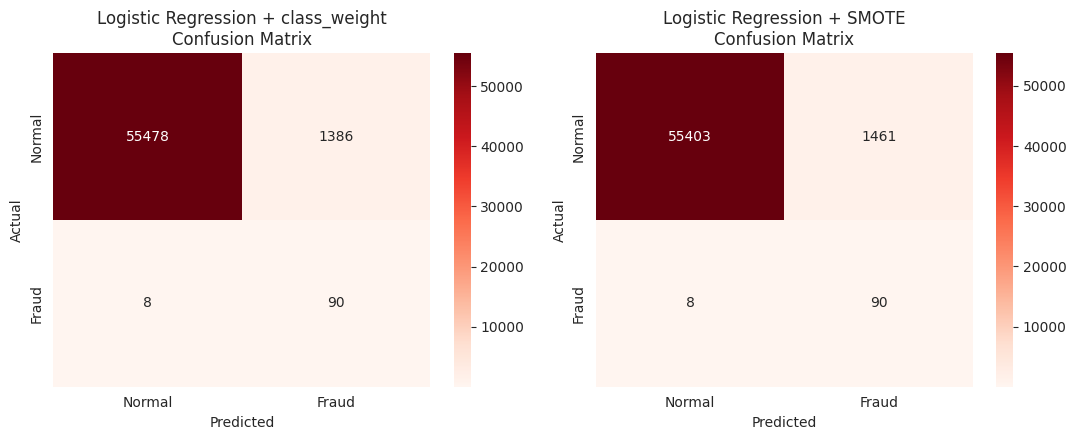

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [('Logistic Regression + class_weight', weighted_pred),
                                     ('Logistic Regression + SMOTE', smote_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Before vs. after:** Both class-weighting and SMOTE substantially increase Recall on the baseline
Logistic Regression — catching far more of the true fraud cases — usually at some cost to Precision (more
false alarms), which is the expected and correct trade-off for fraud detection, where missing real fraud is
far more costly than an extra manual review. The Decision Tree shows the same pattern: class weighting
raises Recall noticeably over the untouched baseline. Accuracy barely moves in any version (it was already
~99.9%), which is exactly why Precision/Recall/F1 — not accuracy — are the metrics that reveal whether the
imbalance fix actually worked.